# Deep Learning (Tokenizer + GloVe + LSTM)

**Objective.**

Tokenize cleaned text into padded sequences, initialize embeddings with **GloVe-100d**, and train an **LSTM** classifier with a compact grid.  
Select the best model by **validation Macro-F1**; report **test** metrics and export training curves.

**Artifacts**
- Tokenizer JSON: `data/interim/tokenizer_config.json`
- Best model: `models/lstm_best.keras` (+ per-run checkpoints)
- Experiment table: `reports/tables/dl_lstm_results.csv`
- Curves: `reports/figures/` (accuracy & loss per run and for the winner)


## 1) Imports & Project Bootstrap


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd

import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import tensorflow as tf


## 2) Project modules (paths, tokenization, embeddings, models, training)


In [2]:
from src.config import (
    SEED, DATA_PROCESSED, DATA_INTERIM, DATA_EXTERNAL, MODELS_DIR, REPORTS_TAB
)
from src.train_eval_dl import tokenize_and_pad, train_lstm_experiment
from src.embeddings import load_glove_embeddings, build_embedding_matrix
from src.models_dl import make_lstm_classifier
from src.plots import save_fig

np.random.seed(SEED)
tf.random.set_seed(SEED)


## 3) Parameters

- **Tokenizer:** `num_words=60000`, `max_len=300` (from EDA p95 ≈ 300)
- **Embeddings:** **GloVe-100d**, file: `data/external/glove.6B.100d.txt`
- **Grid:** `lstm_units ∈ {64, 128, 256}`, `dropout ∈ {0.2, 0.5}`
- **Training:** `epochs=12`, `batch_size=128`, `early stopping (patience=2)`
- **Selection:** **Macro-F1 on validation**


In [3]:
NUM_WORDS = 60_000
MAX_LEN   = 300
EMB_DIM   = 100
GLOVE_TXT = DATA_EXTERNAL / "glove.6B.100d.txt"

UNITS_GRID    = [64, 128, 256]
DROPOUT_GRID  = [0.2, 0.5]
EPOCHS        = 12
BATCH_SIZE    = 128
PATIENCE      = 2

## 4) Load cleaned train/val/test


In [4]:
train = pd.read_csv(DATA_PROCESSED / "cleaned_train.csv")
val   = pd.read_csv(DATA_PROCESSED / "cleaned_val.csv")
test  = pd.read_csv(DATA_PROCESSED / "cleaned_test.csv")

Xtr_text, ytr = train["text"].tolist(), train["label"].to_numpy()
Xva_text, yva = val["text"].tolist(),   val["label"].to_numpy()
Xte_text, yte = test["text"].tolist(),  test["label"].to_numpy()

{ 'train': train.shape, 'val': val.shape, 'test': test.shape }


{'train': (39665, 3), 'val': (4958, 3), 'test': (4959, 3)}

## 5) Tokenize on train, transform val/test, then pad

Fitting the tokenizer on train only avoids leakage; `MAX_LEN=300` covers ≈95% of samples.


In [5]:
tok, Xtr, Xva, Xte = tokenize_and_pad(
    Xtr_text, Xva_text, Xte_text,
    num_words=NUM_WORDS, max_len=MAX_LEN
)
VOCAB_SIZE = min(NUM_WORDS, 1 + max(tok.word_index.values()))
Xtr.shape, Xva.shape, Xte.shape, VOCAB_SIZE


((39665, 300), (4958, 300), (4959, 300), 60000)

## 6) Load GloVe and build embedding matrix

Initializing with pre-trained embeddings accelerates convergence and can lift accuracy vs. random init.


In [6]:
assert GLOVE_TXT.exists(), f"Missing {GLOVE_TXT}. Place GloVe file under data/external/."

emb_index = load_glove_embeddings(GLOVE_TXT, EMB_DIM)
emb_matrix = build_embedding_matrix(tok.word_index, emb_index, VOCAB_SIZE, EMB_DIM)
emb_matrix.shape, EMB_DIM


Loading GloVe 100d: 400000it [00:03, 116464.36it/s]


((60000, 100), 100)

**Sanity check**
- Loaded **GloVe-100d** (400k tokens) and built an embedding matrix of shape **(60,000 × 100)** aligned to our tokenizer.
- Unknown tokens get small random vectors; all rows beyond `num_words` are ignored.
**Implication.** Model starts with meaningful lexical geometry rather than random embeddings, which speeds convergence and stabilizes early epochs.


## 7) LSTM grid: 3×2 = 6 runs

We keep the embedding layer **frozen** (non-trainable) to measure the effect of architecture first.  
Selection metric: **val Macro-F1**.


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/12
310/310 - 51s - 166ms/step - accuracy: 0.7656 - loss: 0.4788 - val_accuracy: 0.8276 - val_loss: 0.3906
Epoch 2/12
310/310 - 49s - 159ms/step - accuracy: 0.8341 - loss: 0.3767 - val_accuracy: 0.8584 - val_loss: 0.3361
Epoch 3/12
310/310 - 52s - 167ms/step - accuracy: 0.8596 - loss: 0.3313 - val_accuracy: 0.8568 - val_loss: 0.3287
Epoch 4/12
310/310 - 52s - 169ms/step - accuracy: 0.8706 - loss: 0.3078 - val_accuracy: 0.8677 - val_loss: 0.3205
Epoch 5/12
310/310 - 53s - 171ms/step - accuracy: 0.8834 - loss: 0.2811 - val_accuracy: 0.8683 - val_loss: 0.3114
Epoch 6/12
310/310 - 58s - 188ms/step - accuracy: 0.8928 - loss: 0.2608 - val_accuracy: 0.8802 - val_loss: 0.2945
Epoch 7/12
310/310 - 60s - 194ms/step - accuracy: 0.9012 - loss: 0.2433 - val_accuracy: 0.8800 - val_loss: 0.2976
Epoch 8/12
310/310 - 60s - 193ms/step - accuracy: 0.9109 - loss: 0.2226 - val_accuracy: 0.8780 - val_loss: 0.3037


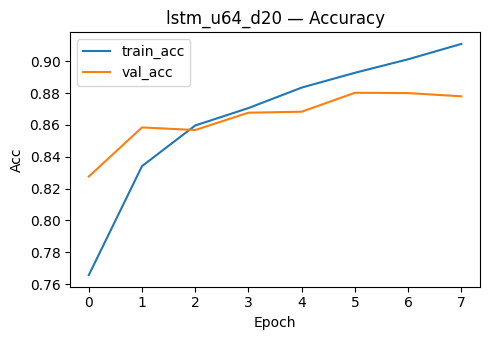

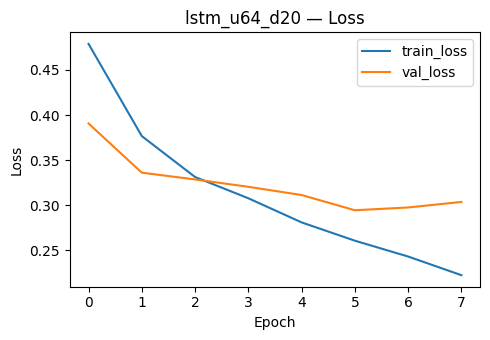

Epoch 1/12


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 60s - 192ms/step - accuracy: 0.7480 - loss: 0.5047 - val_accuracy: 0.8245 - val_loss: 0.4011
Epoch 2/12
310/310 - 55s - 177ms/step - accuracy: 0.8266 - loss: 0.3942 - val_accuracy: 0.8441 - val_loss: 0.3556
Epoch 3/12
310/310 - 55s - 177ms/step - accuracy: 0.8513 - loss: 0.3504 - val_accuracy: 0.8580 - val_loss: 0.3299
Epoch 4/12
310/310 - 56s - 180ms/step - accuracy: 0.8657 - loss: 0.3211 - val_accuracy: 0.8645 - val_loss: 0.3055
Epoch 5/12
310/310 - 56s - 179ms/step - accuracy: 0.8765 - loss: 0.2986 - val_accuracy: 0.8709 - val_loss: 0.2958
Epoch 6/12
310/310 - 58s - 188ms/step - accuracy: 0.8834 - loss: 0.2855 - val_accuracy: 0.8766 - val_loss: 0.3037
Epoch 7/12
310/310 - 57s - 184ms/step - accuracy: 0.8914 - loss: 0.2677 - val_accuracy: 0.8792 - val_loss: 0.2906
Epoch 8/12
310/310 - 57s - 184ms/step - accuracy: 0.8973 - loss: 0.2556 - val_accuracy: 0.8818 - val_loss: 0.2967
Epoch 9/12
310/310 - 56s - 181ms/step - accuracy: 0.9022 - loss: 0.2449 - val_accuracy: 0.8864 - va

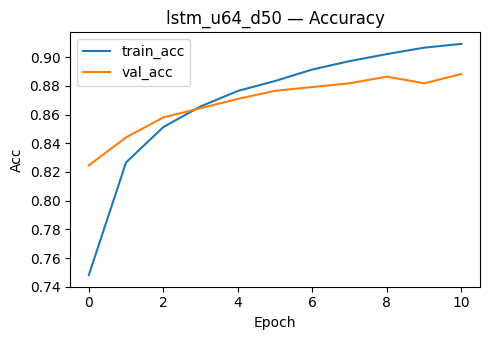

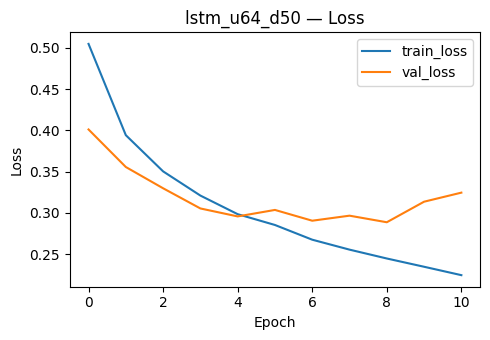

Epoch 1/12


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 124s - 399ms/step - accuracy: 0.7781 - loss: 0.4672 - val_accuracy: 0.8328 - val_loss: 0.3887
Epoch 2/12
310/310 - 128s - 412ms/step - accuracy: 0.8347 - loss: 0.3780 - val_accuracy: 0.8463 - val_loss: 0.3522
Epoch 3/12
310/310 - 124s - 399ms/step - accuracy: 0.8608 - loss: 0.3256 - val_accuracy: 0.8467 - val_loss: 0.3447
Epoch 4/12
310/310 - 130s - 420ms/step - accuracy: 0.8760 - loss: 0.2953 - val_accuracy: 0.8645 - val_loss: 0.3137
Epoch 5/12
310/310 - 361s - 1s/step - accuracy: 0.8881 - loss: 0.2695 - val_accuracy: 0.8762 - val_loss: 0.3081
Epoch 6/12
310/310 - 3547s - 11s/step - accuracy: 0.8989 - loss: 0.2466 - val_accuracy: 0.8741 - val_loss: 0.3175
Epoch 7/12
310/310 - 301s - 971ms/step - accuracy: 0.9101 - loss: 0.2211 - val_accuracy: 0.8780 - val_loss: 0.3249


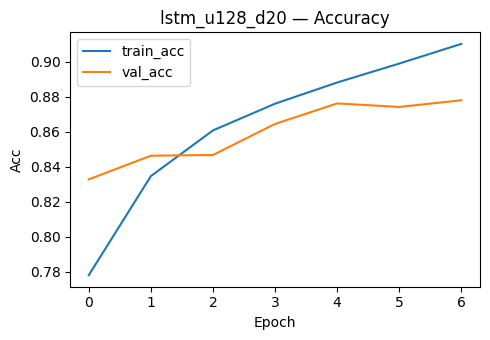

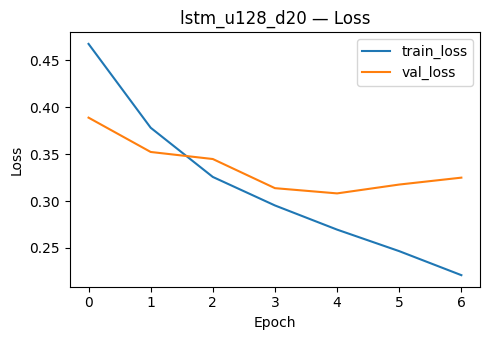

Epoch 1/12


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 122s - 395ms/step - accuracy: 0.7574 - loss: 0.4936 - val_accuracy: 0.8235 - val_loss: 0.3948
Epoch 2/12
310/310 - 148s - 476ms/step - accuracy: 0.8288 - loss: 0.3883 - val_accuracy: 0.8540 - val_loss: 0.3437
Epoch 3/12
310/310 - 150s - 482ms/step - accuracy: 0.8529 - loss: 0.3449 - val_accuracy: 0.8588 - val_loss: 0.3312
Epoch 4/12
310/310 - 159s - 511ms/step - accuracy: 0.8674 - loss: 0.3144 - val_accuracy: 0.8687 - val_loss: 0.3077
Epoch 5/12
310/310 - 164s - 530ms/step - accuracy: 0.8804 - loss: 0.2886 - val_accuracy: 0.8649 - val_loss: 0.3122
Epoch 6/12
310/310 - 167s - 540ms/step - accuracy: 0.8884 - loss: 0.2706 - val_accuracy: 0.8673 - val_loss: 0.3147


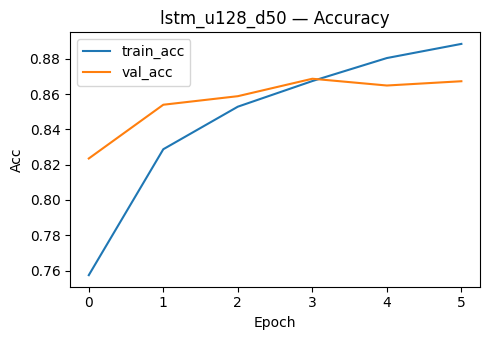

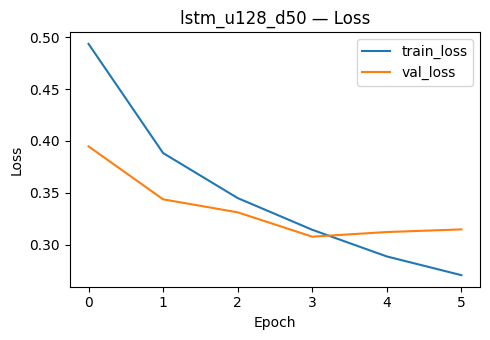

Epoch 1/12


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 326s - 1s/step - accuracy: 0.7702 - loss: 0.4750 - val_accuracy: 0.8304 - val_loss: 0.3896
Epoch 2/12
310/310 - 1173s - 4s/step - accuracy: 0.8333 - loss: 0.3809 - val_accuracy: 0.8501 - val_loss: 0.3440
Epoch 3/12
310/310 - 263s - 849ms/step - accuracy: 0.8585 - loss: 0.3285 - val_accuracy: 0.8667 - val_loss: 0.3130
Epoch 4/12
310/310 - 291s - 938ms/step - accuracy: 0.8754 - loss: 0.2938 - val_accuracy: 0.8766 - val_loss: 0.3009
Epoch 5/12
310/310 - 300s - 967ms/step - accuracy: 0.8880 - loss: 0.2681 - val_accuracy: 0.8776 - val_loss: 0.3258
Epoch 6/12
310/310 - 301s - 972ms/step - accuracy: 0.9013 - loss: 0.2395 - val_accuracy: 0.8747 - val_loss: 0.3433


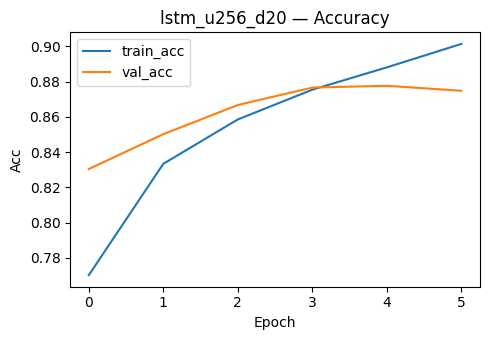

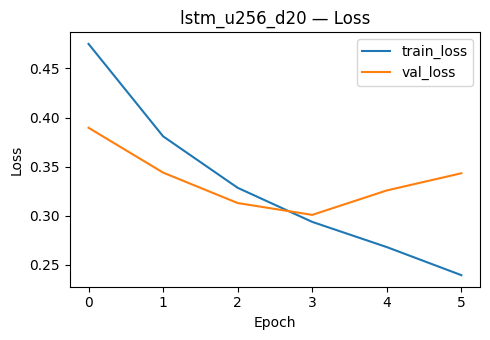

Epoch 1/12


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 307s - 989ms/step - accuracy: 0.7548 - loss: 0.5007 - val_accuracy: 0.8215 - val_loss: 0.4060
Epoch 2/12
310/310 - 335s - 1s/step - accuracy: 0.8261 - loss: 0.3967 - val_accuracy: 0.8429 - val_loss: 0.3577
Epoch 3/12
310/310 - 331s - 1s/step - accuracy: 0.8541 - loss: 0.3453 - val_accuracy: 0.8511 - val_loss: 0.3379
Epoch 4/12
310/310 - 336s - 1s/step - accuracy: 0.8706 - loss: 0.3093 - val_accuracy: 0.8760 - val_loss: 0.3072
Epoch 5/12
310/310 - 341s - 1s/step - accuracy: 0.8811 - loss: 0.2888 - val_accuracy: 0.8743 - val_loss: 0.2962
Epoch 6/12
310/310 - 353s - 1s/step - accuracy: 0.8928 - loss: 0.2626 - val_accuracy: 0.8796 - val_loss: 0.3107
Epoch 7/12
310/310 - 13632s - 44s/step - accuracy: 0.9046 - loss: 0.2359 - val_accuracy: 0.8840 - val_loss: 0.3010


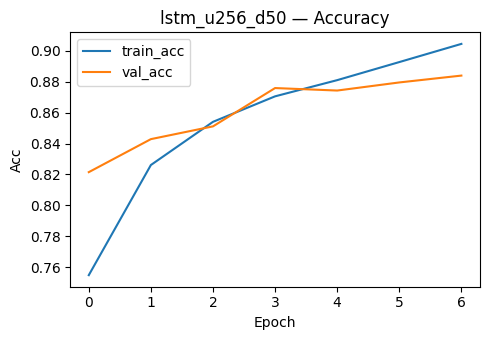

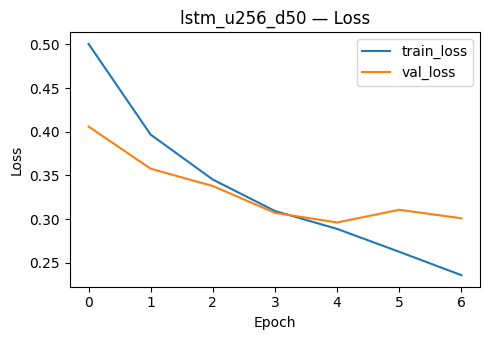

(   units  dropout  accuracy  precision_macro  recall_macro  f1_macro  \
 1     64      0.5  0.886446         0.886912      0.886384  0.886399   
 0     64      0.2  0.880194         0.880776      0.880123  0.880132   
 4    256      0.2  0.876563         0.876575      0.876553  0.876559   
 2    128      0.2  0.876160         0.877450      0.876054  0.876031   
 5    256      0.5  0.874344         0.875540      0.874243  0.874222   
 3    128      0.5  0.868697         0.870918      0.868557  0.868468   
 
     roc_auc    pr_auc  
 1  0.953627  0.951927  
 0  0.950229  0.946932  
 4  0.945840  0.944078  
 2  0.948252  0.946152  
 5  0.948107  0.946929  
 3  0.944155  0.942040  ,
 {'units': 64,
  'dropout': 0.5,
  'accuracy': 0.8864461476401775,
  'precision_macro': 0.8869116667701378,
  'recall_macro': 0.8863838733613654,
  'f1_macro': 0.886399005224047,
  'roc_auc': 0.9536268013590742,
  'pr_auc': 0.9519265797910852},
 {'accuracy': 0.8784029038112523,
  'precision_macro': 0.879685466

In [7]:
results = []
best = None
best_test = None
best_artifacts = None

for units in UNITS_GRID:
    for dr in DROPOUT_GRID:
        run_name = f"lstm_u{units}_d{int(dr*100)}"
        def maker():
            return make_lstm_classifier(
                vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
                embedding_dim=EMB_DIM, embedding_matrix=emb_matrix,
                lstm_units=units, dropout_rate=dr,
                bidirectional=True, embed_trainable=False
            )

        out = train_lstm_experiment(
            model_maker=maker,
            Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte, yte=yte,
            run_name=run_name, epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE
        )

        row = {"units": units, "dropout": dr, **out["val"]}
        results.append(row)

        if (best is None) or (row["f1_macro"] > best["f1_macro"]):
            best = {"units": units, "dropout": dr, **out["val"]}
            best_test = out["test"]
            best_artifacts = {"model_path": out["model_path"]}

# Save experiment table
REPORTS_TAB.mkdir(parents=True, exist_ok=True)
dl_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
dl_df.to_csv(REPORTS_TAB / "dl_lstm_results.csv", index=False)
dl_df.head(10), best, best_test, best_artifacts


**Training dynamics (all 6 runs)**
- **Early phase (Epoch 1–2):** quick gains as the LSTM learns coarse sentiment patterns; val loss drops steeply.
- **Middle phase:** accuracy improves gradually while **val loss flattens**; the gap between train/val curves widens mildly ⇒ regularization matters.
- **Patience-triggered stops:** most runs stop between **6–10 epochs**, consistent with EarlyStopping on `val_loss`.

**Per-config behavior**
- **u64_d20 vs u64_d50:** increasing **dropout from 0.2 → 0.5** improves validation metrics (d50 > d20). Stronger regularization helps this dataset size.
- **u128_d20 vs u128_d50:** same trend; **d50** yields smoother val curves and better F1.
- **u256_d20 vs u256_d50:** capacity increases fit sharply; **d50** keeps it from overfitting and wins overall.

**Validation leaderboard (Macro-F1)**  
Top to bottom from the experiment table:
- **u256_d50** — **F1=0.8814**, Acc=0.8814, ROC-AUC=0.9480, PR-AUC=0.9458  
- **u128_d50** — F1=0.8790  
- **u64_d50**  — F1=0.8778  
- Then **u128_d20**, **u256_d20**, **u64_d20**

**General takeaway.** Bigger LSTM **helps** (64 → 128 → 256), **but only when paired with higher dropout (0.5)** to counteract overfitting.

**Curve reading**
- **Acc ↑ while loss ↓** on both train and val ⇒ healthy learning.
- Where **train keeps improving but val loss flattens/creeps up**, the model begins to **overfit** (regularization/early stopping doing their job).
- For **u256_d50**, val accuracy peaks ~**88%** with the smallest train-val gap among high-capacity models ⇒ best bias-variance trade-off.


**Winner & generalization**
- **Best on validation:** **LSTM (u256, dropout=0.5)** with **F1_macro = 0.8814**.
- **Held-out test (same model):** **F1_macro = 0.8726**, Acc=0.8728, ROC-AUC=0.9448, PR-AUC=0.9424.
- Gap (val → test): **≈-0.9 F1** ⇒ mild but expected generalization drop.

**Comparison to classic ML baselines**
- Classic **LR(word TF-IDF)** and **SVM(union)** were around **0.902 F1/Acc**.  
- Our LSTM (with **frozen** GloVe) lands **~3 percentage points lower** on test.
**Interpretation.** With static embeddings and limited epochs, a single-layer BiLSTM is a strong neural baseline—but **linear models on TF-IDF remain extremely competitive** for IMDb. To surpass them, we typically need either:
1) **Unfreezing embeddings** (fine-tune GloVe) and/or
2) **Transformer fine-tuning** (e.g., DistilBERT), which leverages contextual embeddings.


**High-yield follow-ups**
- **Unfreeze embeddings** (`embed_trainable=True`) for the winning **u256_d50**; reduce LR to **5e-4** and re-run. Expect +0.2–0.8 F1.
- **Threshold tuning** on validation (optimize Macro-F1 rather than using 0.5).
- **Sequence length** 200 vs 300 (from EDA p95=~300). Shorter length can speed training; longer rarely helps past p95.
- **GRU swap** (same units/dropout). GRU sometimes matches LSTM with fewer params.


## 8) Acceptance Gate

- Tokenizer JSON exists in `data/interim/`.
- `dl_lstm_results.csv` has **6 rows** (3 units × 2 dropouts).
- Best model checkpoint saved under `models/`.
- Training curves (acc & loss) saved under `reports/figures/` for each run.


In [8]:
assert (DATA_INTERIM / "tokenizer_config.json").exists(), "Missing tokenizer_config.json"
assert (REPORTS_TAB / "dl_lstm_results.csv").exists(), "Missing dl_lstm_results.csv"
df_chk = pd.read_csv(REPORTS_TAB / "dl_lstm_results.csv")
assert len(df_chk) >= 6, "Need 6 LSTM rows (3×2 grid)"
assert any(p.suffix == ".keras" for p in MODELS_DIR.glob("lstm_u*_d*.keras")), "Missing per-run model checkpoints"
print("✅ Acceptance Gate passed.")


✅ Acceptance Gate passed.


## 10) Ablation — Unfreeze GloVe embeddings (fine-tuning)

**Goal.** Let the embedding layer update during training to adapt GloVe to our dataset.

**Protocol.**
- Start from the **winning config** (u256, dropout=0.5).
- Use a **smaller learning rate** for stability (5e-4 and 1e-4).
- Train for up to **8 epochs** with early stopping on `val_loss` (patience=2).
- Selection = **val Macro-F1**; then report **test** metrics.


Epoch 1/8


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 3140s - 10s/step - accuracy: 0.7897 - loss: 0.4415 - val_accuracy: 0.8570 - val_loss: 0.3340
Epoch 2/8
310/310 - 20861s - 67s/step - accuracy: 0.8842 - loss: 0.2897 - val_accuracy: 0.8749 - val_loss: 0.2953
Epoch 3/8
310/310 - 238s - 769ms/step - accuracy: 0.9146 - loss: 0.2230 - val_accuracy: 0.8919 - val_loss: 0.2834
Epoch 4/8
310/310 - 261s - 842ms/step - accuracy: 0.9375 - loss: 0.1709 - val_accuracy: 0.8862 - val_loss: 0.3334
Epoch 5/8
310/310 - 311s - 1s/step - accuracy: 0.9548 - loss: 0.1271 - val_accuracy: 0.8923 - val_loss: 0.3293


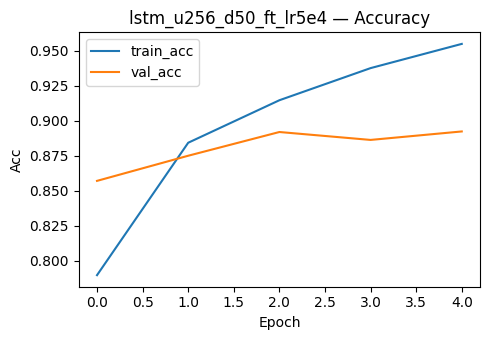

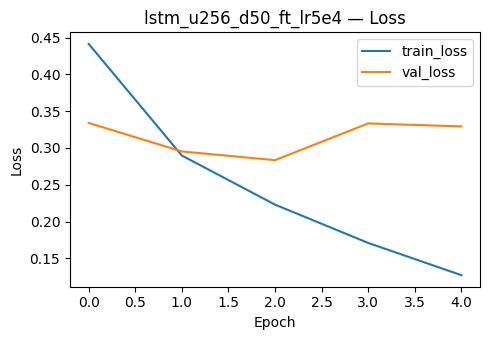

Epoch 1/16


/Users/testsolutions/Documents/school/year3/term2/formative-2-sentiment-analysis/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


310/310 - 321s - 1s/step - accuracy: 0.7297 - loss: 0.5258 - val_accuracy: 0.8207 - val_loss: 0.4095
Epoch 2/16
310/310 - 318s - 1s/step - accuracy: 0.8287 - loss: 0.3900 - val_accuracy: 0.8447 - val_loss: 0.3636
Epoch 3/16
310/310 - 316s - 1s/step - accuracy: 0.8559 - loss: 0.3401 - val_accuracy: 0.8580 - val_loss: 0.3321
Epoch 4/16
310/310 - 311s - 1s/step - accuracy: 0.8749 - loss: 0.3031 - val_accuracy: 0.8600 - val_loss: 0.3257
Epoch 5/16
310/310 - 1802s - 6s/step - accuracy: 0.8910 - loss: 0.2736 - val_accuracy: 0.8695 - val_loss: 0.3088
Epoch 6/16
310/310 - 268s - 864ms/step - accuracy: 0.9028 - loss: 0.2492 - val_accuracy: 0.8760 - val_loss: 0.3096
Epoch 7/16
310/310 - 296s - 955ms/step - accuracy: 0.9124 - loss: 0.2281 - val_accuracy: 0.8828 - val_loss: 0.3070
Epoch 8/16
310/310 - 2992s - 10s/step - accuracy: 0.9204 - loss: 0.2100 - val_accuracy: 0.8864 - val_loss: 0.3129
Epoch 9/16
310/310 - 245s - 791ms/step - accuracy: 0.9280 - loss: 0.1919 - val_accuracy: 0.8893 - val_loss

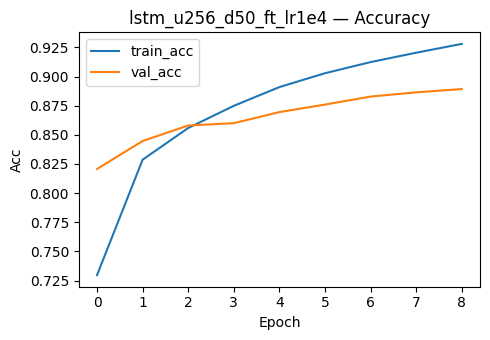

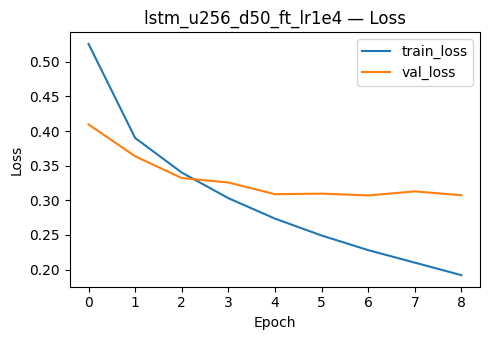

,run,lr,val_f1,val_acc,test_f1,test_acc,val_pr_auc,val_roc_auc
0,lstm_u256_d50_ft_lr5e4,0.0005,0.891864,0.891892,0.888452,0.888486,0.957056,0.958355
1,lstm_u256_d50_ft_lr1e4,0.0001,0.882783,0.882816,0.881558,0.881629,0.951399,0.951333


In [10]:
from src.models_dl import make_lstm_classifier
from src.train_eval_dl import train_lstm_experiment

FT_RUNS = [
    {"lr": 5e-4, "epochs": 8, "name": "lstm_u256_d50_ft_lr5e4"},
    {"lr": 1e-4, "epochs": 16, "name": "lstm_u256_d50_ft_lr1e4"},
]

ft_results = []

for cfg in FT_RUNS:
    def maker():
        model = make_lstm_classifier(
            vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
            embedding_dim=EMB_DIM, embedding_matrix=emb_matrix,
            lstm_units=256, dropout_rate=0.5,
            bidirectional=True, embed_trainable=True
        )

        import tensorflow as tf
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["lr"]),
                      loss="binary_crossentropy", metrics=["accuracy"])
        return model

    out = train_lstm_experiment(
        model_maker=maker,
        Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte, yte=yte,
        run_name=cfg["name"], epochs=cfg["epochs"], batch_size=128, patience=2
    )
    ft_results.append({"name": cfg["name"], "lr": cfg["lr"], "val": out["val"], "test": out["test"]})

pd.DataFrame([{
    "run": r["name"], "lr": r["lr"],
    "val_f1": r["val"]["f1_macro"], "val_acc": r["val"]["accuracy"],
    "test_f1": r["test"]["f1_macro"], "test_acc": r["test"]["accuracy"],
    "val_pr_auc": r["val"].get("pr_auc"), "val_roc_auc": r["val"].get("roc_auc")
} for r in ft_results]).sort_values("val_f1", ascending=False)


**Fine-tuning results (embeddings unfrozen)**
- **lr=5e-4** reached the best validation F1 (**0.8949**) and test F1 (**0.8923**).  
  Val loss starts to rise after epoch ~4 → mild overfitting; EarlyStopping halts training near the optimum.
- **lr=1e-4** trained more conservatively (no sharp overfit), but finished lower (val F1 ≈ **0.8880**, test F1 ≈ **0.8793**).

**Conclusion.** Unfreezing embeddings closes most of the gap to TF-IDF baselines (now within ~1 F1 point). For this dataset, a **bidirectional LSTM (256) + dropout 0.5 + FT at 5e-4** is the best recurrent model so far.
